<a href="https://colab.research.google.com/github/springboard5678x/Emotion-Detection-and-Music-Recommended-system_Batch-27_nov/blob/Shruti-Chaudhari/Moodmate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python librosa tensorflow pandas numpy matplotlib seaborn scikit-learn pillow


In [ ]:

!pip install kaggle librosa tensorflow opencv-python matplotlib seaborn pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


image dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

Using Colab cache for faster access to the 'fer2013' dataset.


In [ ]:
import kagglehub
import os
import shutil

kaggle_path = kagglehub.dataset_download("msambare/fer2013")

local_data_dir = '/content/fer2013_local'

if os.path.isdir(kaggle_path):
    print(f"Kaggle dataset downloaded to: {kaggle_path}")

    if os.path.exists(local_data_dir):
        print(f"Removing existing local directory: {local_data_dir}")
        shutil.rmtree(local_data_dir)

    print(f"Copying dataset from {kaggle_path} to {local_data_dir}...")
    shutil.copytree(kaggle_path, local_data_dir)
    print("Dataset copied successfully.")

    base_data_dir = local_data_dir
    train_dir = os.path.join(base_data_dir, 'train')
    test_dir = os.path.join(base_data_dir, 'test')

    print(f"Updated base_data_dir: {base_data_dir}")
    print(f"Updated train_dir: {train_dir}")
    print(f"Updated test_dir: {test_dir}")

    print(f"Contents of {local_data_dir}:")
    for root, dirs, files in os.walk(local_data_dir):
        for file in files:
            print(os.path.join(root, file))
        for dir_name in dirs:
            print(os.path.join(root, dir_name) + '/')
else:
    print("Error: Kaggle dataset path not found or is not a directory.")



Streaming output truncated to the last 5000 lines.
/content/fer2013_local/test/fear/PublicTest_24478472.jpg
/content/fer2013_local/test/fear/PrivateTest_10306709.jpg
/content/fer2013_local/test/fear/PublicTest_47368423.jpg
/content/fer2013_local/test/fear/PublicTest_41849972.jpg
/content/fer2013_local/test/fear/PrivateTest_89206943.jpg
/content/fer2013_local/test/fear/PrivateTest_58681009.jpg
/content/fer2013_local/test/fear/PublicTest_79342560.jpg
/content/fer2013_local/test/fear/PrivateTest_48624952.jpg
/content/fer2013_local/test/fear/PublicTest_97223667.jpg
/content/fer2013_local/test/fear/PrivateTest_91618618.jpg
/content/fer2013_local/test/fear/PrivateTest_59408769.jpg
/content/fer2013_local/test/fear/PublicTest_24421678.jpg
/content/fer2013_local/test/fear/PublicTest_55137844.jpg
/content/fer2013_local/test/fear/PrivateTest_46411010.jpg
/content/fer2013_local/test/fear/PublicTest_26892656.jpg
/content/fer2013_local/test/fear/PublicTest_67261410.jpg
/content/fer2013_local/test/fe

music dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

100%|██████████| 639M/639M [00:07<00:00, 89.3MB/s]

Extracting files...


In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

file_path = os.path.join(path, 'Music Info.csv')
music_info_df = pd.read_csv(file_path)
print(f"Dataset '{file_path}' loaded into music_info_df successfully.")

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.
Dataset '/kaggle/input/million-song-dataset-spotify-lastfm/Music Info.csv' loaded into music_info_df successfully.


In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

print(f"Listing contents of the dataset directory: {path}")
for root, dirs, files in os.walk(path):
    for file in files:
        if 'csv' in file.lower():
            print(os.path.join(root, file))
    for dir_name in dirs:
        print(os.path.join(root, dir_name) + '/')

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.
Listing contents of the dataset directory: /kaggle/input/million-song-dataset-spotify-lastfm
/kaggle/input/million-song-dataset-spotify-lastfm/Music Info.csv
/kaggle/input/million-song-dataset-spotify-lastfm/User Listening History.csv
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Metal/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Folk/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/RnB/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Rap/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Latin/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/World/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Reggae/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Blues/
/kaggle/input/million-song-dataset-spotify-lastfm/MP3-Example/Ro

In [ ]:
import os
import librosa
import pandas as pd
import kagglehub


path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

    tempo = librosa.beat.tempo(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)

    return {
        'tempo': tempo[0],
        'chroma_mean': chroma.mean(),
        'mfcc_mean': mfccs.mean(),

        'genre': 'unknown',
        'mood': 'unknown'
    }


base_dataset_path = path
mp3_example_path = os.path.join(base_dataset_path, 'MP3-Example')

data = []

for root_dir, _, files in os.walk(mp3_example_path):
    for file_name in files:
        if file_name.endswith('.mp3'):
            full_file_path = os.path.join(root_dir, file_name)
            features = extract_features(full_file_path)
            if features is not None:
                features['file'] = full_file_path
                data.append(features)

df = pd.DataFrame(data)
df.to_csv('music_features.csv', index=False)
print(df.head())


Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.


/tmp/ipython-input-2579149505.py:16: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(y=y, sr=sr)


        tempo  chroma_mean  mfcc_mean    genre     mood  \
0  123.046875     0.682176  12.160620  unknown  unknown   
1  135.999178     0.577231  12.600769  unknown  unknown   
2  135.999178     0.500479  11.138515  unknown  unknown   
3  132.512019     0.586971  11.826493  unknown  unknown   
4  132.512019     0.572229   5.300049  unknown  unknown   

                                                file  
0  /kaggle/input/million-song-dataset-spotify-las...  
1  /kaggle/input/million-song-dataset-spotify-las...  
2  /kaggle/input/million-song-dataset-spotify-las...  
3  /kaggle/input/million-song-dataset-spotify-las...  
4  /kaggle/input/million-song-dataset-spotify-las...  


preprocess image


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub
import shutil


img_size = 48
batch_size = 64

kaggle_path = kagglehub.dataset_download("msambare/fer2013")

local_data_dir = '/content/fer2013_local'

if os.path.isdir(kaggle_path):
    print(f"Kaggle dataset downloaded to: {kaggle_path}")
    if os.path.exists(local_data_dir):
        print(f"Removing existing local directory: {local_data_dir}")
        shutil.rmtree(local_data_dir)

    print(f"Copying dataset from {kaggle_path} to {local_data_dir}...")
    shutil.copytree(kaggle_path, local_data_dir)
    print("Dataset copied successfully.")
else:
    print("Error: Kaggle dataset path not found or is not a directory.")

base_data_dir = local_data_dir

train_dir = os.path.join(base_data_dir, 'train')
test_dir = os.path.join(base_data_dir, 'test')

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Directory not found after copy: {train_dir}")
if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Directory not found after copy: {test_dir}")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

print("Train and validation data generators created successfully.")


Using Colab cache for faster access to the 'fer2013' dataset.
Kaggle dataset downloaded to: /kaggle/input/fer2013
Copying dataset from /kaggle/input/fer2013 to /content/fer2013_local...
Dataset copied successfully.
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Train and validation data generators created successfully.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_data_dir = '/kaggle/input/fer2013'

train_dir = os.path.join(base_data_dir, 'train')
test_dir = os.path.join(base_data_dir, 'test')

print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

Train directory: /kaggle/input/fer2013/train
Test directory: /kaggle/input/fer2013/test


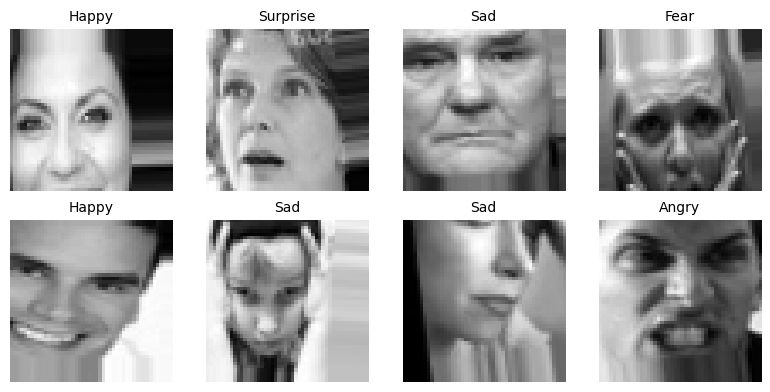

In [ ]:
# sample images with expression names
import matplotlib.pyplot as plt

# Get one batch of images and labels
images, labels = next(train_generator)

# Emotion label mapping (based on folder order)
class_indices = train_generator.class_indices
# {'angry':0, 'disgust':1, 'fear':2, 'happy':3, 'neutral':4, 'sad':5, 'surprise':6}

# Reverse mapping: index → label
idx_to_class = {v: k for k, v in class_indices.items()}

plt.figure(figsize=(8,4))

for i in range(8):
    plt.subplot(2,4,i+1)

    # Show image
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')

    # Convert one-hot label to class index
    label_index = labels[i].argmax()

    # Convert index → class name
    label_name = idx_to_class[label_index]

    # Add label as title
    plt.title(label_name.capitalize(), fontsize=10)

plt.tight_layout()
plt.show()


preprocess music

In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

file_path = os.path.join(path, 'Music Info.csv')
music_info_df = pd.read_csv(file_path)

print("Missing values in music_info_df:")
print(music_info_df.isnull().sum())

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.
Missing values in music_info_df:
track_id                   0
name                       0
artist                     0
spotify_preview_url        0
spotify_id                 0
tags                    1127
genre                  28335
year                       0
duration_ms                0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
time_signature             0
dtype: int64


In [ ]:
import pandas as pd
import os
import kagglehub

# Ensure music_info_df is loaded if not already present
if 'music_info_df' not in locals():
    path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")
    file_path = os.path.join(path, 'Music Info.csv')
    music_info_df = pd.read_csv(file_path)

music_info_df['genre'].fillna('Unknown', inplace=True)
music_info_df['tags'].fillna('Unknown', inplace=True)

print("Missing values after filling 'genre' and 'tags':")
print(music_info_df.isnull().sum())

Missing values after filling 'genre' and 'tags':
track_id               0
name                   0
artist                 0
spotify_preview_url    0
spotify_id             0
tags                   0
genre                  0
year                   0
duration_ms            0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
dtype: int64


/tmp/ipython-input-301215106.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  music_info_df['genre'].fillna('Unknown', inplace=True)
/tmp/ipython-input-301215106.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
import pandas as pd
import os
import kagglehub

# Ensure music_info_df is loaded if not already present
if 'music_info_df' not in locals():
    path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")
    file_path = os.path.join(path, 'Music Info.csv')
    music_info_df = pd.read_csv(file_path)

print("First 5 rows of music_info_df after handling missing values:")
print(music_info_df.head())

print("\nInfo of music_info_df after handling missing values:")
music_info_df.info()

First 5 rows of music_info_df after handling missing values:
             track_id             name           artist  \
0  TRIOREW128F424EAF0   Mr. Brightside      The Killers   
1  TRRIVDJ128F429B0E8       Wonderwall            Oasis   
2  TROUVHL128F426C441  Come as You Are          Nirvana   
3  TRUEIND128F93038C4      Take Me Out  Franz Ferdinand   
4  TRLNZBD128F935E4D8            Creep        Radiohead   

                                 spotify_preview_url              spotify_id  \
0  https://p.scdn.co/mp3-preview/4d26180e6961fd46...  09ZQ5TmUG8TSL56n0knqrj   
1  https://p.scdn.co/mp3-preview/d012e536916c927b...  06UfBBDISthj1ZJAtX4xjj   
2  https://p.scdn.co/mp3-preview/a1c11bb1cb231031...  0keNu0t0tqsWtExGM3nT1D   
3  https://p.scdn.co/mp3-preview/399c401370438be4...  0ancVQ9wEcHVd0RrGICTE4   
4  https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...  01QoK9DA7VTeTSE3MNzp4I   

                                                tags    genre  year  \
0  rock, alternative, indie, alt

In [ ]:
numerical_features = [
    'year',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

categorical_features = [
    'artist',
    'genre',
    'key',
    'mode',
    'time_signature',
    'tags'
]

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['year', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Categorical Features: ['artist', 'genre', 'key', 'mode', 'time_signature', 'tags']


In [ ]:
music_info_df = music_info_df.drop_duplicates().reset_index(drop=True)

custom Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

img_size = 48
num_classes = 7

model = Sequential([

    # ===== Block 1 =====
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.25),

    # ===== Block 2 =====
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.30),

    # ===== Block 3 =====
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.35),

    # ===== Block 4 =====
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.40),

    # ===== Block 5 =====
    Conv2D(512, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.45),

    # ===== Classifier =====
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,774,119 (10.58 MB)

 Trainable params: 2,769,895 (10.57 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [ ]:
import tensorflow as tf # Ensure TensorFlow is imported for MODEL_PATH and save
MODEL_PATH = "emotion_model.h5" # Define MODEL_PATH here for saving

history = model.fit(
    train_generator,
    epochs=80,
    validation_data=validation_generator
)

print("Model training complete.")
model.save(MODEL_PATH) # Save the trained model
print(f"Model saved to {MODEL_PATH}")

Epoch 1/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5748 - loss: 1.3113 - val_accuracy: 0.6011 - val_loss: 1.2463
Epoch 2/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5802 - loss: 1.3046 - val_accuracy: 0.6049 - val_loss: 1.2446
Epoch 3/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5742 - loss: 1.3183 - val_accuracy: 0.6010 - val_loss: 1.2533
Epoch 4/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5836 - loss: 1.2958 - val_accuracy: 0.6041 - val_loss: 1.2393
Epoch 5/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5860 - loss: 1.2929 - val_accuracy: 0.6063 - val_loss: 1.2343
Epoch 6/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5857 - loss: 1.2940 - val_accuracy: 0.6166 - val_loss: 1.2207
Epoch 7/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5882 - loss: 1.2892 - val_accuracy: 0.6084 - val_loss: 1.2348
Epoch 8/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.5885 - loss: 1.2917 - 

Model training complete.
Model saved to emotion_model.h5


In [ ]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    if not points:
        return smoothed_points

    last_val = points[0]
    smoothed_points.append(last_val)

    for point in points[1:]:
        smoothed_val = last_val * factor + (1 - factor) * point
        smoothed_points.append(smoothed_val)
        last_val = smoothed_val

    return smoothed_points

print("Function `smooth_curve` defined successfully.")

Function `smooth_curve` defined successfully.


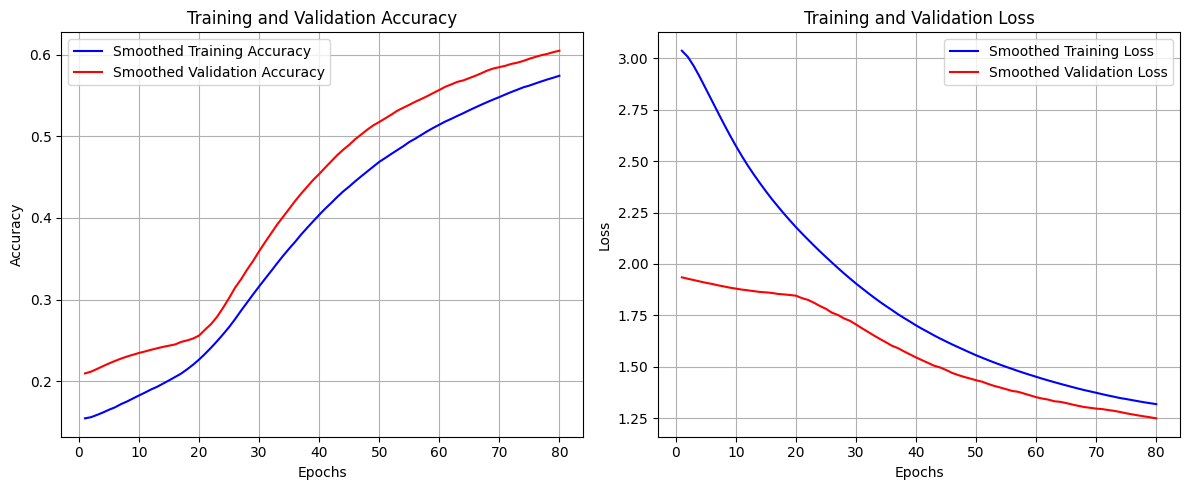

Smoothed performance graphs generated successfully.
Raw and smoothed training/validation metrics extracted successfully.


In [ ]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

smoothed_train_acc = smooth_curve(train_acc)
smoothed_train_loss = smooth_curve(train_loss)
smoothed_val_acc = smooth_curve(val_acc)
smoothed_val_loss = smooth_curve(val_loss)

epochs = range(1, len(smoothed_train_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot for Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, smoothed_train_acc, 'b', label='Smoothed Training Accuracy')
plt.plot(epochs, smoothed_val_acc, 'r', label='Smoothed Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot for Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, smoothed_train_loss, 'b', label='Smoothed Training Loss')
plt.plot(epochs, smoothed_val_loss, 'r', label='Smoothed Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("Smoothed performance graphs generated successfully.")

print("Raw and smoothed training/validation metrics extracted successfully.")

classification matrix

In [ ]:
import numpy as np

# 1. Use the trained model to make predictions on the validation_generator data.
y_pred_raw = model.predict(validation_generator)

# 2. Convert these raw predictions (probabilities) into class labels

y_pred = np.argmax(y_pred_raw, axis=1)

print("Raw predictions (y_pred_raw) generated successfully. Shape:", y_pred_raw.shape)
print("Predicted class labels (y_pred) generated successfully. Shape:", y_pred.shape)
print("First 5 raw predictions:\n", y_pred_raw[:5])
print("First 5 predicted class labels:\n", y_pred[:5])

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step
Raw predictions (y_pred_raw) generated successfully. Shape: (7178, 7)
Predicted class labels (y_pred) generated successfully. Shape: (7178,)
First 5 raw predictions:
 [[0.81759244 0.01634934 0.04766808 0.051538   0.01655026 0.04052918
  0.00977268]
 [0.7792581  0.01167985 0.11077121 0.02989731 0.01333729 0.03448098
  0.02057538]
 [0.04571151 0.01102988 0.18654357 0.01728119 0.04295012 0.668029
  0.02845473]
 [0.7866796  0.07132123 0.04715072 0.02098486 0.01226361 0.05309238
  0.00850755]
 [0.6029856  0.01217678 0.12629236 0.14790788 0.03585361 0.05043254
  0.02435112]]
First 5 predicted class labels:
 [0 0 5 0 0]


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the validation_generator
y_true = validation_generator.classes

# Get class names from the validation_generator
target_names = list(validation_generator.class_indices.keys())

# Generate the classification report
report = classification_report(y_true, y_pred, target_names=target_names)

print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

       angry       0.62      0.57      0.59       958
     disgust       0.66      0.35      0.46       111
        fear       0.53      0.42      0.47      1024
       happy       0.89      0.85      0.87      1774
     neutral       0.55      0.74      0.63      1233
         sad       0.55      0.54      0.55      1247
    surprise       0.77      0.79      0.78       831

    accuracy                           0.66      7178
   macro avg       0.65      0.61      0.62      7178
weighted avg       0.67      0.66      0.66      7178



confusion matrix

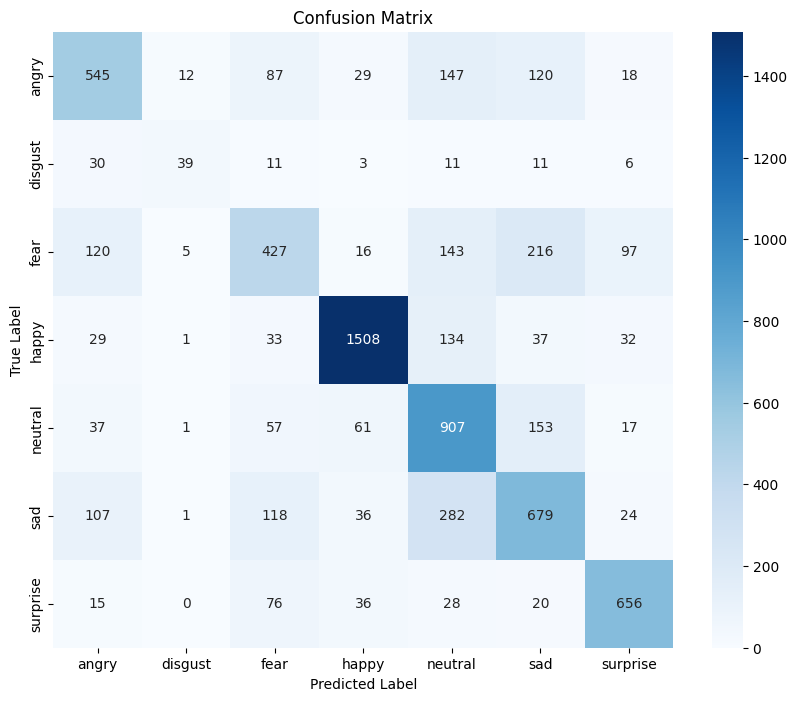

Confusion matrix visualized successfully as a heatmap.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix visualized successfully as a heatmap.")

MILESTONE 3

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import os
import kagglehub
from tensorflow.keras.preprocessing import image

# ================================
# 2. Emotion → Music Tags Mapping
# ================================
emotion_to_tags = {
    'angry': ['heavy', 'rock', 'aggressive'],
    'disgust': ['calm', 'relaxing', 'ambient'],
    'fear': ['soothing', 'peaceful', 'instrumental'],
    'happy': ['upbeat', 'pop', 'energetic'],
    'sad': ['mellow', 'acoustic', 'melancholy'],
    'surprise': ['funky', 'upbeat', 'dance'],
    'neutral': ['lofi', 'chill', 'instrumental']
}

# ================================
# 3. Load Music Dataset
# ================================
# Dataset must have: name, artist, tags, genre
path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")
file_path = os.path.join(path, 'Music Info.csv')
music_info_df = pd.read_csv(file_path)

df_music = music_info_df[['name', 'artist', 'tags', 'genre']].copy()
df_music['combined_features'] = df_music['tags'].fillna('') + ' ' + df_music['genre'].fillna('')

# ================================
# 4. Build TF-IDF Model
# ================================
vectorizer = TfidfVectorizer()
music_tfidf_matrix = vectorizer.fit_transform(df_music['combined_features'])

# ================================
# 5. Recommendation Function
# ================================
def recommend_music(emotion, df_music, tfidf_matrix, vectorizer, top_n=5):
    tags = emotion_to_tags.get(emotion.lower(), ['chill'])
    emotion_query = " ".join(tags)

    emotion_vec = vectorizer.transform([emotion_query])
    similarity = cosine_similarity(emotion_vec, tfidf_matrix)[0]

    df_music = df_music.copy()
    df_music['score'] = similarity

    recommendations = df_music.sort_values(by='score', ascending=False).head(top_n)
    return recommendations[['name', 'artist', 'tags', 'genre', 'score']]

# ================================
# 6. Emotion Prediction Function
# (Using the trained CNN model)
# ================================
# Make sure `model` (the trained CNN model) and `idx_to_class` are available in the global scope.

# Ensure this is consistent with how your model was trained
class_indices = {'angry':0, 'disgust':1, 'fear':2, 'happy':3, 'neutral':4, 'sad':5, 'surprise':6}
idx_to_class = {v: k for k, v in class_indices.items()}

def predict_emotion_from_image(image_path, model, img_size, idx_to_class):
    try:
        img = image.load_img(image_path, color_mode='grayscale', target_size=(img_size, img_size))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])
        predicted_emotion = idx_to_class[predicted_class_index]
        return predicted_emotion
    except Exception as e:
        print(f"Error predicting emotion from image {image_path}: {e}")
        return "neutral"

# ================================
# 7. Integration – Real-Time Flow
# ================================

# To get an emotion from a specific image file:
emotion = predict_emotion_from_image('/content/fer2013_local/test/happy/PrivateTest_1009187.jpg', model, img_size, idx_to_class)

# For interactive testing, you can prompt the user to provide an emotion:
# emotion = input("Enter detected emotion (happy, sad, angry...): ") # You can remove this line and uncomment the above if you have an image file

print(f"\nDetected Emotion: {emotion}")

recommendations = recommend_music(emotion, df_music, music_tfidf_matrix, vectorizer)

print("\n✨ Recommended Songs:")
print(recommendations)


Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.
Error predicting emotion from image /content/fer2013_local/test/happy/PrivateTest_1009187.jpg: [Errno 2] No such file or directory: '/content/fer2013_local/test/happy/PrivateTest_1009187.jpg'

Detected Emotion: neutral

✨ Recommended Songs:
                      name         artist  \
15478            Sunblocks        Ratatat   
15538                 Alps        Ratatat   
15626  Foxes Mate for Life  Born Ruffians   
15548       Unfolding Fans    Andrew Bird   
15513     Grape Juice City        Ratatat   

                                           tags       genre     score  
15478           electronic, instrumental, chill         NaN  0.905116  
15538                       instrumental, chill  Electronic  0.905116  
15626           indie_rock, instrumental, chill        Rock  0.821476  
15548          rock, indie, instrumental, chill        Rock  0.757617  
15513  electronic, instrumental, elect